# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
import os

print(os.getcwd())
print(os.path.exists('scripts/datasets/cifar-10-batches-py'))
print(os.listdir('scripts/datasets'))

D:\мага\нейронные сети и глубокое обучение\lab_1-2
True
['cifar-10-batches-py', 'get_datasets.sh']


In [3]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('размер обучающих данных -', X_train.shape)
print('размер обучающих меток -', y_train.shape)
print('размер тестовых данных -', X_test.shape)
print('размер тестовых меток -', y_test.shape)

размер обучающих данных - (50000, 32, 32, 3)
размер обучающих меток - (50000,)
размер тестовых данных - (10000, 32, 32, 3)
размер тестовых меток - (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



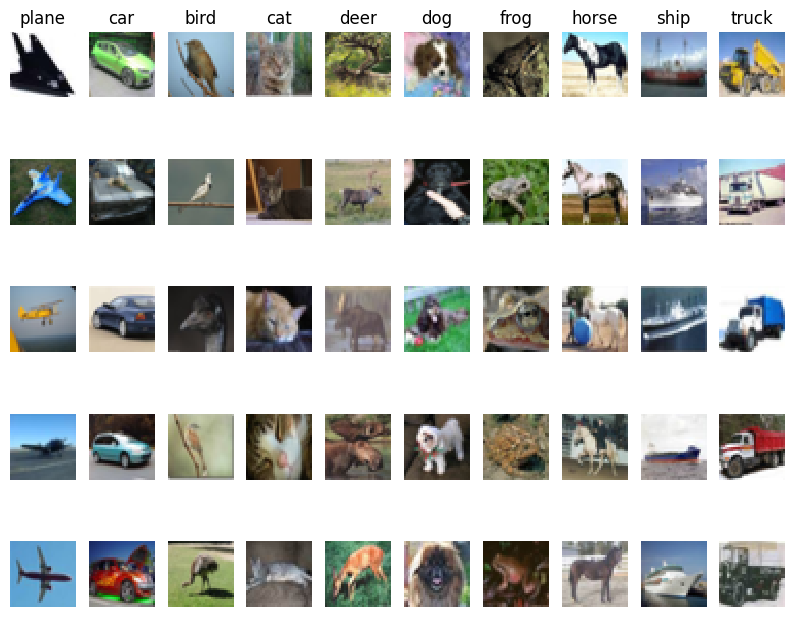

In [4]:
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

num_classes = len(classes)
num_examples = 5

for i in range(num_classes):
    indexes = np.where(y_train == i)[0]
    indexes = np.random.choice(indexes, num_examples, replace=False)

    for j in range(num_examples):
        plt.subplot(num_examples, num_classes, j * num_classes + i + 1)
        plt.imshow(X_train[indexes[j]].astype('uint8'))
        plt.axis('off')

        if j == 0:
            plt.title(classes[i])

plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [5]:
X_train = X_train[:5000]
y_train = y_train[:5000]

X_test = X_test[:500]
y_test = y_test[:500]

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (5000, 3072)
y_train: (5000,)
X_test: (500, 3072)
y_test: (500,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [6]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [7]:
dists = classifier.compute_distances_no_loops(X_test)

y_test_pred = classifier.predict_labels(dists, k=1)

print('первые 20 предсказаний')
print(y_test_pred[:20])

print('правильные классы')
print(y_test[:20])

первые 20 предсказаний
[4. 9. 8. 8. 4. 4. 3. 2. 5. 8. 2. 8. 5. 7. 2. 2. 5. 3. 1. 4.]
правильные классы
[3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


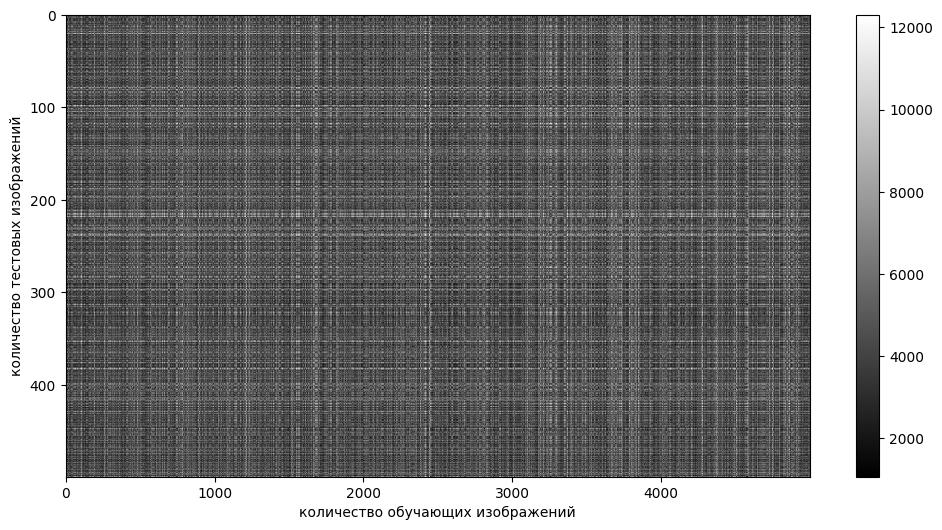

In [8]:
plt.figure(figsize=(12, 6))
plt.imshow(dists, aspect='auto')
plt.xlabel('количество обучающих изображений')
plt.ylabel('количество тестовых изображений')
plt.colorbar()
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [9]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = num_correct / y_test.shape[0]

print('правильных -', num_correct)
print('точность -', accuracy)

правильных -  137
точность -  0.274


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

k = 1 accuracy = 0.274
k = 3 accuracy = 0.272
k = 5 accuracy = 0.278
k = 7 accuracy = 0.274
k = 9 accuracy = 0.268
k = 11 accuracy = 0.262
k = 15 accuracy = 0.272


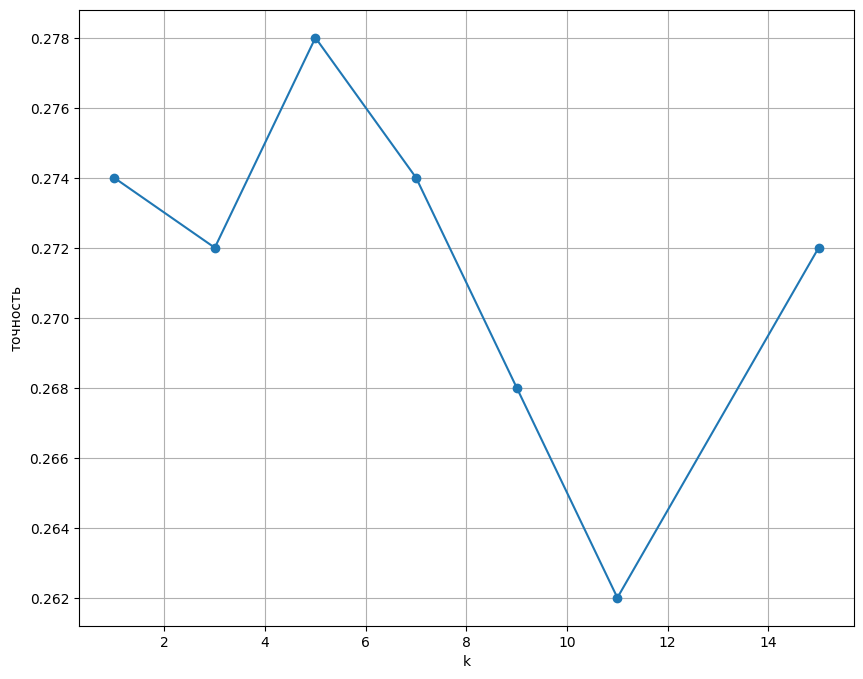

In [10]:
k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []

for k in k_values:
    y_pred = classifier.predict_labels(dists, k=k)
    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)

    print('k =', k, 'accuracy =', acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('точность')
plt.grid()
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [11]:
num_folds = 5
k_choices = [1, 3, 5, 7, 9, 11]

X_folds = np.array_split(X_train, num_folds)
y_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []

In [12]:
for i in range(num_folds):
    X_val = X_folds[i]
    y_val = y_folds[i]

    X_train_cv = np.vstack(
        [X_folds[j] for j in range(num_folds) if j != i]
    )

    y_train_cv = np.hstack(
        [y_folds[j] for j in range(num_folds) if j != i]
    )

    classifier_cv = KNearestNeighbor()
    classifier_cv.train(X_train_cv, y_train_cv)

    dists_cv = classifier_cv.compute_distances_no_loops(X_val)

    for k in k_choices:
        y_val_pred = classifier_cv.predict_labels(dists_cv, k=k)

        acc = np.mean(y_val_pred == y_val)
        k_to_accuracies[k].append(acc)

In [13]:
for k in k_choices:
    print('k =', k)
    print(k_to_accuracies[k])
    print('средняя точность =', np.mean(k_to_accuracies[k]))
    print()

k = 1
[np.float64(0.263), np.float64(0.257), np.float64(0.264), np.float64(0.278), np.float64(0.266)]
средняя точность = 0.2656

k = 3
[np.float64(0.239), np.float64(0.249), np.float64(0.24), np.float64(0.266), np.float64(0.254)]
средняя точность = 0.2496

k = 5
[np.float64(0.248), np.float64(0.266), np.float64(0.28), np.float64(0.292), np.float64(0.28)]
средняя точность = 0.2732

k = 7
[np.float64(0.261), np.float64(0.279), np.float64(0.268), np.float64(0.288), np.float64(0.276)]
средняя точность = 0.27440000000000003

k = 9
[np.float64(0.259), np.float64(0.283), np.float64(0.27), np.float64(0.285), np.float64(0.285)]
средняя точность = 0.2764

k = 11
[np.float64(0.265), np.float64(0.296), np.float64(0.277), np.float64(0.279), np.float64(0.27)]
средняя точность = 0.2774



In [14]:
best_k = k_choices[0]
best_accuracy = 0

for k in k_choices:
    mean_accuracy = np.mean(k_to_accuracies[k])

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_k = k

print('лучшее k -', best_k)
print('лучшая точность на валидации -', best_accuracy)

лучшее k - 11
лучшая точность на валидации - 0.2774


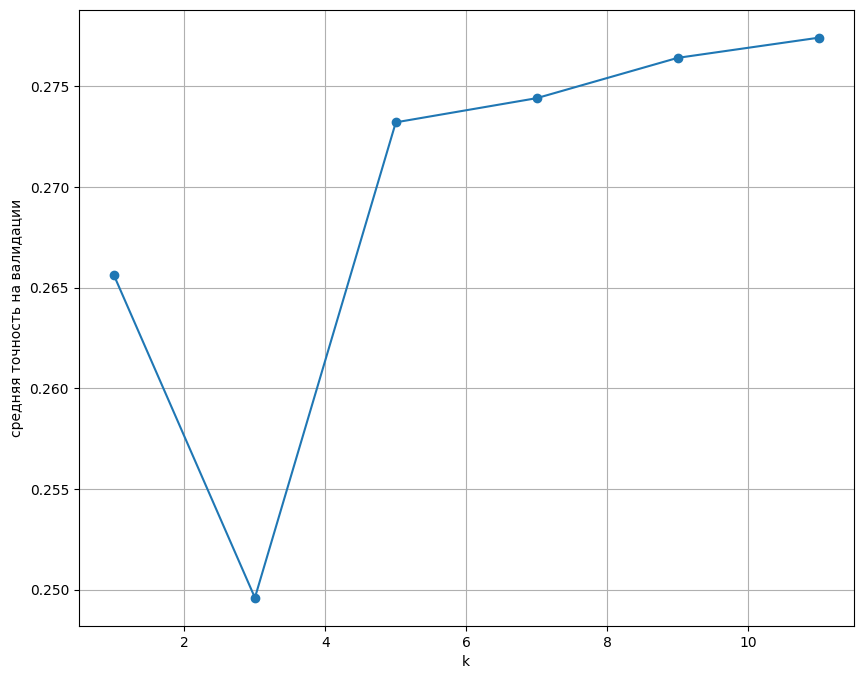

In [15]:
mean_accuracies = []

for k in k_choices:
    mean_accuracies.append(np.mean(k_to_accuracies[k]))

plt.plot(k_choices, mean_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('средняя точность на валидации')
plt.grid()
plt.show()


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [16]:
classifier_best = KNearestNeighbor()
classifier_best.train(X_train, y_train)

y_test_pred = classifier_best.predict(X_test, k=best_k)

accuracy = np.mean(y_test_pred == y_test)

print('лучшее значение k -', best_k)
print('точность на тестовой выборке -', accuracy)

лучшее значение k - 11
точность на тестовой выборке - 0.262


1.11 Сделайте выводы по результатам 1 части задания.

In [ ]:
"В первой части работы был реализован метод k ближайших соседей для классификации изображений CIFAR-10. При использовании одного ближайшего соседа точность на тестовой выборке составила 0.274. Также была проверена зависимость точности от значения k. На обычной тестовой выборке результаты для разных значений k отличались не очень сильно. После проведения кросс-валидации лучшее значение получилось равным 11, при этом средняя точность на валидации составила 0.2774. После использования выбранного значения k точность на тестовой выборке составила 0.262. Полученные результаты показывают, что увеличение числа соседей не всегда приводит к улучшению качества классификации"

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [17]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

X_val = X_train[num_training:num_training + num_validation]
y_val = y_train[num_training:num_training + num_validation]

X_train = X_train[:num_training]
y_train = y_train[:num_training]

X_test = X_test[:num_test]
y_test = y_test[:num_test]

dev_indexes = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[dev_indexes]
y_dev = y_train[dev_indexes]

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
X_dev = X_dev.reshape(X_dev.shape[0], -1)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)
print('X_dev:', X_dev.shape)
print('y_dev:', y_dev.shape)

X_train: (49000, 3072)
y_train: (49000,)
X_val: (1000, 3072)
y_val: (1000,)
X_test: (1000, 3072)
y_test: (1000,)
X_dev: (500, 3072)
y_dev: (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


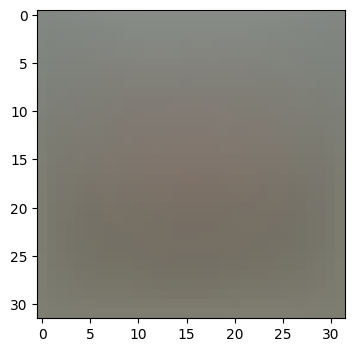

(49000, 3073)
(1000, 3073)
(1000, 3073)
(500, 3073)


In [18]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image



X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(X_dev.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [19]:
from scripts.classifiers.linear_svm import svm_loss_naive
import time


W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.636409



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [20]:
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 6.070747 analytic: 6.070747, relative error: 2.581384e-11
numerical: 24.008681 analytic: 24.012413, relative error: 7.773187e-05
numerical: 11.700457 analytic: 11.700457, relative error: 7.579661e-12
numerical: -16.336183 analytic: -16.336183, relative error: 1.384708e-11
numerical: -1.689768 analytic: -1.689768, relative error: 1.641168e-10
numerical: 0.548168 analytic: 0.487401, relative error: 5.868047e-02
numerical: 9.653674 analytic: 9.653674, relative error: 9.821631e-12
numerical: 20.646159 analytic: 20.646159, relative error: 2.786689e-12
numerical: 4.321582 analytic: 4.321582, relative error: 1.053935e-11
numerical: -9.576477 analytic: -9.576477, relative error: 3.743259e-11
numerical: -3.879026 analytic: -3.879026, relative error: 6.694643e-11
numerical: -2.003384 analytic: -2.003384, relative error: 2.534802e-11
numerical: 21.364241 analytic: 21.364241, relative error: 6.929992e-12
numerical: 16.930976 analytic: 16.930976, relative error: 8.288488e-13
numerical: -

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [21]:
from scripts.classifiers.linear_svm import svm_loss_vectorized
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('потеря и градиент на простой реализации - вычислено за %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Потеря и градиент на векторизованной реализации - вычислено за %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('разница - %f' % difference)

потеря и градиент на простой реализации - вычислено за 0.037861s
Потеря и градиент на векторизованной реализации - вычислено за 0.002494s
разница - 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [22]:
from scripts.classifiers.linear_classifier import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('время обучения %fs' % (toc - tic))

iteration 0 / 1500: loss 792.526412
iteration 100 / 1500: loss 286.537859
iteration 200 / 1500: loss 107.826085
iteration 300 / 1500: loss 42.537976
iteration 400 / 1500: loss 19.219114
iteration 500 / 1500: loss 10.076713
iteration 600 / 1500: loss 7.008592
iteration 700 / 1500: loss 6.146432
iteration 800 / 1500: loss 5.545933
iteration 900 / 1500: loss 5.614219
iteration 1000 / 1500: loss 5.282628
iteration 1100 / 1500: loss 5.105112
iteration 1200 / 1500: loss 4.925117
iteration 1300 / 1500: loss 5.092422
iteration 1400 / 1500: loss 5.758666
время обучения 3.096964s


In [23]:
y_train_pred = svm.predict(X_train)
print('точность на обучении - %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('точность на валидации - %f' % (np.mean(y_val == y_val_pred), ))

точность на обучении - 0.374673
точность на валидации - 0.376000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [24]:
learning_rates = [1e-7, 2e-7, 5e-7]
regularization_strengths = [1e4, 2.5e4, 5e4]

In [25]:
results = {}

best_val = 0
best_svm = None
best_lr = None
best_reg = None

for lr in learning_rates:
    for reg in regularization_strengths:
        svm_model = LinearSVM()

        svm_model.train(
            X_train,
            y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=500,
            verbose=False
        )

        train_pred = svm_model.predict(X_train)
        val_pred = svm_model.predict(X_val)

        train_acc = np.mean(train_pred == y_train)
        val_acc = np.mean(val_pred == y_val)

        results[(lr, reg)] = (train_acc, val_acc)

        print('lr =', lr,
              'reg =', reg,
              'train =', train_acc,
              'val =', val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_svm = svm_model
            best_lr = lr
            best_reg = reg

lr = 1e-07 reg = 10000.0 train = 0.3218979591836735 val = 0.337
lr = 1e-07 reg = 25000.0 train = 0.36018367346938773 val = 0.378
lr = 1e-07 reg = 50000.0 train = 0.35777551020408166 val = 0.374
lr = 2e-07 reg = 10000.0 train = 0.36548979591836733 val = 0.376
lr = 2e-07 reg = 25000.0 train = 0.3550204081632653 val = 0.361
lr = 2e-07 reg = 50000.0 train = 0.34455102040816327 val = 0.356
lr = 5e-07 reg = 10000.0 train = 0.34430612244897957 val = 0.348
lr = 5e-07 reg = 25000.0 train = 0.34789795918367344 val = 0.356
lr = 5e-07 reg = 50000.0 train = 0.3153673469387755 val = 0.32


In [26]:
print()
print('лучшая скорость обучения -', best_lr)
print('лучшая регуляризация -', best_reg)
print('лучшая точность на валидации -', best_val)


лучшая скорость обучения - 1e-07
лучшая регуляризация - 25000.0
лучшая точность на валидации - 0.378


In [27]:
best_svm = LinearSVM()

loss_hist = best_svm.train(
    X_train,
    y_train,
    learning_rate=best_lr,
    reg=best_reg,
    num_iters=1500,
    verbose=True)

iteration 0 / 1500: loss 786.600952
iteration 100 / 1500: loss 286.358451
iteration 200 / 1500: loss 107.638809
iteration 300 / 1500: loss 42.948606
iteration 400 / 1500: loss 19.070109
iteration 500 / 1500: loss 10.346497
iteration 600 / 1500: loss 6.815187
iteration 700 / 1500: loss 5.702194
iteration 800 / 1500: loss 5.911941
iteration 900 / 1500: loss 5.313926
iteration 1000 / 1500: loss 5.240363
iteration 1100 / 1500: loss 5.046956
iteration 1200 / 1500: loss 5.565849
iteration 1300 / 1500: loss 5.181716
iteration 1400 / 1500: loss 5.295079


In [28]:
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test_pred == y_test)

print('точность на тесте -', test_accuracy)

точность на тесте - 0.373


In [29]:
train_accuracy = np.mean(best_svm.predict(X_train) == y_train)
val_accuracy = np.mean(best_svm.predict(X_val) == y_val)
test_accuracy = np.mean(best_svm.predict(X_test) == y_test)

print('точность на обучении -', train_accuracy)
print('точность на валидации -', val_accuracy)
print('точность на тесте -', test_accuracy)

точность на обучении - 0.36820408163265306
точность на валидации - 0.381
точность на тесте - 0.373


2.9 Сделайте выводы по второй части задания

In [ ]:
"Во второй части работы был реализован линейный SVM классификатор. Были реализованы обычный и векторизованный способы вычисления функции потерь и градиента. Векторизованная версия работала значительно быстрее. Обычная реализация выполнялась примерно за 0.038 секунды, а векторизованная примерно за 0.0025 секунды. При этом разница между полученными градиентами была равна нулю, что показывает одинаковый результат обеих реализаций. При обучении значение функции потерь заметно уменьшилось примерно с 786 до значений около 5. После подбора параметров лучшая скорость обучения составила 1e-7, а коэффициент регуляризации 25000. Точность после итогового обучения составила примерно 0.368 на обучающей выборке, 0.381 на валидационной и 0.373 на тестовой. По сравнению с kNN метод SVM показал более высокую точность"